Battery Rul


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [5]:
df = pd.read_csv("Battery_RUL.csv")
features_to_remove = ['Charging time (s)', 'Time constant current (s)', 'Time at 4.15V (s)','Cycle_Index']
df.drop(columns=features_to_remove, inplace=True)
df.head()

,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),RUL
0,2595.30,1151.488500,3.670,3.211,1112
1,7408.64,1172.512500,4.246,3.220,1111
2,7393.76,1112.992000,4.249,3.224,1110
3,7385.50,1080.320667,4.250,3.225,1109
4,65022.75,29813.487000,4.290,3.398,1107


In [7]:
n = len(df)
train = df.iloc[: int(0.7 * n)]
valid = df.iloc[int(0.7 * n) : int(0.85 * n)]
test = df.iloc[int(0.85 * n) :]

print(len(train), len(valid), len(test))

10544 2260 2260


In [8]:
train.shape

(10544, 5)

In [9]:
valid.shape

(2260, 5)

In [10]:
x_train = train.drop(columns="RUL")
y_train = train["RUL"]
x_valid = valid.drop(columns="RUL")
y_valid = valid["RUL"]
x_test = test.drop(columns="RUL")
y_test = test["RUL"]
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_valid = scaler.transform(x_valid)
x_test = scaler.transform(x_test)

Ridge Model

In [12]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train, y_train)
y_pred = ridge_model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R²: {r2}")
x=1
y="string"


RMSE: 216.6585830852755
R²: 0.5789447521316944


Gradient Bosst

Gradient boosting

In [13]:
gb_model = GradientBoostingRegressor(
    n_estimators=250,           # Slightly increased from 200
    learning_rate=0.04,         # Slightly reduced from 0.05
    max_depth=4,                # Keep the same
    min_samples_split=4,        # Slightly reduced from 5
    min_samples_leaf=2,         # Added for stability
    subsample=0.85,             # Light stochastic sampling
    random_state=42
)

gb_model.fit(x_train,y_train)
y_pred_gb= gb_model.predict(x_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
print(f"\nGradient Boosting RMSE: {rmse_gb:.2f}")
print(f"Gradient Boosting R²: {r2_gb:.4f}")

plt.scatter(y_test, gb_model.predict(x_test), alpha=0.4)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

errors = gb_model.predict(x_test) - y_test

plt.scatter(y_test, errors, alpha=0.4)
plt.axhline(0, color="red")
plt.xlabel("Actual RUL")
plt.ylabel("Prediction Error")
plt.show()
np.

SyntaxError: invalid syntax (3524028873.py, line 33)

In [9]:
features = test.drop(columns="RUL").columns

for i in range(10):
    sample_df = test.loc[[test.index[i]], features]  # keep as DataFrame
    sample_scaled = scaler.transform(sample_df)

    pred = gb_model.predict(sample_scaled)[0]
    actual = test.loc[test.index[i], "RUL"]
    error = abs(pred - actual)

    print(f"Sample {i}: Predicted={pred:.2f}, Actual={actual}, Error={error:.2f}")

NameError: name 'gb_model' is not defined

Lightgdm

Starting Battery RUL Training...
Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 60.0164	validation's rmse: 64.5651
[200]	training's rmse: 37.1025	validation's rmse: 43.8581
[300]	training's rmse: 33.4067	validation's rmse: 41.1546
[400]	training's rmse: 31.475	validation's rmse: 39.4194
[500]	training's rmse: 29.9325	validation's rmse: 38.3758
[600]	training's rmse: 28.6618	validation's rmse: 37.4691
[700]	training's rmse: 27.5135	validation's rmse: 36.6529
[800]	training's rmse: 26.5163	validation's rmse: 36.1214
[900]	training's rmse: 25.6509	validation's rmse: 35.558
[1000]	training's rmse: 24.9666	validation's rmse: 35.1666
[1100]	training's rmse: 24.1339	validation's rmse: 34.5822
[1200]	training's rmse: 23.5545	validation's rmse: 34.301
[1300]	training's rmse: 23.0011	validation's rmse: 34.0547
[1400]	training's rmse: 22.4216	validation's rmse: 33.8019
[1500]	training's rmse: 21.935	validation's rmse: 33.4911
[1600]	training's rmse: 21.4955	va

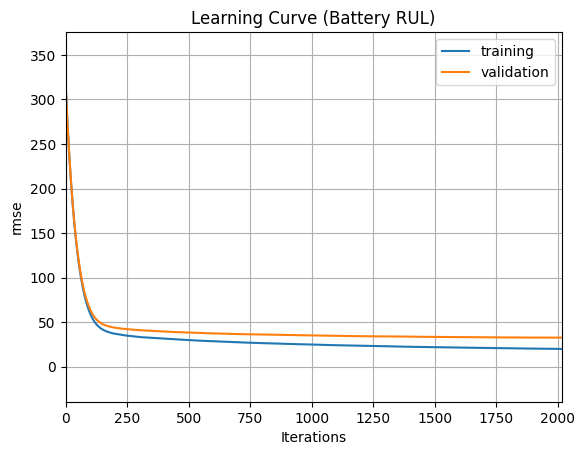


--- Final Evaluation ---
RMSE: 32.67
R²: 0.9897


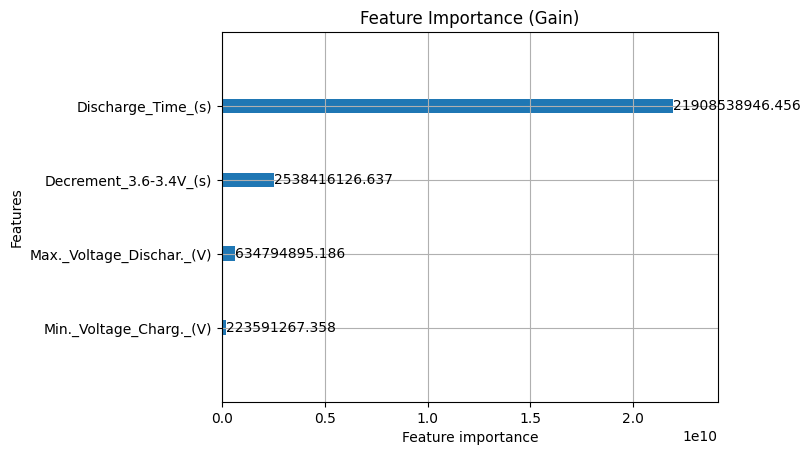

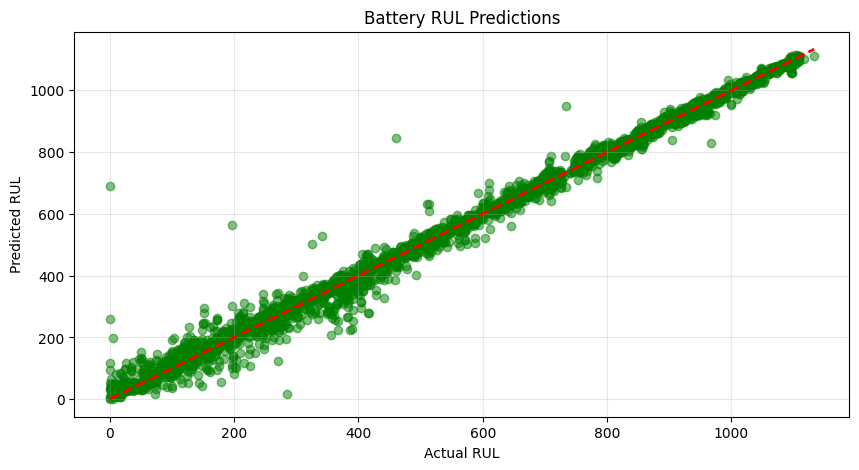

In [14]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# --- 1. Data Setup (Assuming you have loaded your dataframe as 'df') ---
# If you haven't split yet, here is a standard split
X = df.drop(columns=['RUL'])
y = df['RUL']

# Split into Train (80%) and Test (20%)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create LightGBM Datasets
# Note: We are NOT clipping the target here because Battery RUL is usually linear.
train_data = lgb.Dataset(x_train, label=y_train)
valid_data = lgb.Dataset(x_test, label=y_test, reference=train_data)

# --- 2. Hyperparameters for Battery Data ---
# Batteries are "smoother" than engines, so we can use a slightly higher learning rate
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,      # Slightly faster than the engine model
    'num_leaves': 31,           # Standard complexity
    'max_depth': -1,            # Let the tree grow deep (batteries have less noise)
    'feature_fraction': 0.9,    # Use 90% of features
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# --- 3. Training ---
evals_result = {}  # Store metrics history

print("Starting Battery RUL Training...")
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    valid_names=['training', 'validation'],
    num_boost_round=5000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # Stop if no improvement for 50 rounds
        lgb.log_evaluation(period=100),
        lgb.record_evaluation(evals_result)     # Record history
    ]
)

# --- 4. Plot Learning Curve ---
try:
    lgb.plot_metric(evals_result, metric='rmse')
    plt.title("Learning Curve (Battery RUL)")
    plt.show()
except Exception as e:
    print(f"Plot error: {e}")

# --- 5. Final Evaluation ---
print("\n--- Final Evaluation ---")
y_pred = model.predict(x_test)
y_pred = np.maximum(y_pred, 0) # RUL cannot be negative

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

# --- 6. Feature Importance (Check which physics feature is best) ---
lgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.title("Feature Importance (Gain)")
plt.show()

# --- 7. Prediction vs Actual Plot ---
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Battery RUL Predictions")
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Prepare the Data (Assuming X_train and y_train are already defined)
X = df.drop(columns=['RUL'])
y = df['RUL']

# Split into Train (80%) and Test (20%)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# XGBoost works best with its own 'DMatrix' format, but also accepts DataFrames
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)

# 2. Define Hyperparameters
# These are tuned for battery sensor data
params = {
    'objective': 'reg:squarederror', # Regression task
    'max_depth': 6,                  # Depth of the trees
    'eta': 0.1,                      # Learning rate
    'subsample': 0.8,                # Randomly sample 80% of data per tree
    'colsample_bytree': 0.8,         # Randomly sample 80% of features per tree
    'eval_metric': 'rmse'            # Monitoring Root Mean Squared Error
}

# 3. Train the Model
# We'll run it for 100 rounds
num_round = 100
xgb_model = xgb.train(params, dtrain, num_round)

# 4. Predict
y_pred_xgb = xgb_model.predict(dtest)

# 5. Evaluate
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"--- XGBoost Results ---")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R² Score: {r2_xgb:.4f}")

--- XGBoost Results ---
RMSE: 35.4142
R² Score: 0.9879


In [11]:
import pandas as pd

sample_data = {
    'Discharge Time (s)': [2595.30],
    'Decrement 3.6-3.4V (s)': [1151.488],
    'Max. Voltage Dischar. (V)': [3.670],
    'Min. Voltage Charg. (V)': [3.211],
}


input_df = pd.DataFrame(sample_data)


predicted_rul = model.predict(input_df)[0]
actual_rul = 1112 

print(f"--- Single Point Verification ---")
print(f"Input Features: {list(sample_data.values())}")
print(f"\nPredicted RUL: {predicted_rul:.2f}")
print(f"Actual RUL:    {actual_rul}")
print(f"Difference:    {predicted_rul - actual_rul:.2f}")

--- Single Point Verification ---
Input Features: [[2595.3], [1151.488], [3.67], [3.211]]

Predicted RUL: 1107.14
Actual RUL:    1112
Difference:    -4.86


saving best lightgdm model

In [12]:
import joblib

filename = 'battery_rul_model.pkl'


joblib.dump(model, filename)

print(f" Model saved successfully as '{filename}'")

 Model saved successfully as 'battery_rul_model.pkl'


In [12]:
import joblib
# Save the new, lightweight model
joblib.dump(model, 'battery_rul_realtime_4features.pkl')

['battery_rul_realtime_4features.pkl']

LOad the model

In [23]:
import joblib
import pandas as pd

loaded_model = joblib.load('battery_rul_model.pkl')

print("Model loaded successfully")

input_values = [[1341.62, 369.50000, 3.870, 3.616, 2306.3120, 3104.31, 10777.82]]

prediction = loaded_model.predict(input_values)[0]
print(f"Predicted RUL from loaded model: {prediction:.2f}")

Model loaded successfully
Predicted RUL from loaded model: 340.16
